# Chapter 9

Add your content here.

Training Flow Matching Model...
Epoch 0, Loss: 4.3040
Epoch 200, Loss: 0.3666
Epoch 400, Loss: 0.2211
Epoch 600, Loss: 0.2245
Epoch 800, Loss: 0.2756

Running Inference (generating trajectory)...


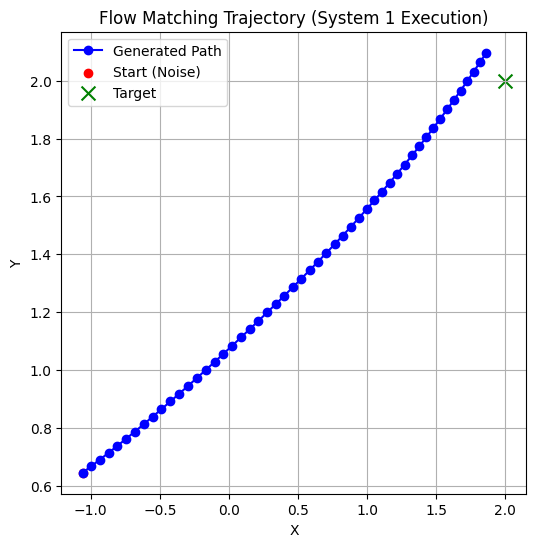

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt

# 1. Define the Vector Field Network (The "Action Head")
# This simple MLP takes (position, time) and predicts velocity (dx/dt, dy/dt)
class VelocityField(nn.Module):
    def __init__(self):
        super().__init__()
        # Input: 2 (x,y pos) + 1 (time) = 3
        self.net = nn.Sequential(
            nn.Linear(3, 64),
            nn.Tanh(),
            nn.Linear(64, 64),
            nn.Tanh(),
            nn.Linear(64, 2) # Output: velocity vector (vx, vy)
        )
    
    def forward(self, x, t):
        # Concatenate position and time
        t_embed = t.view(-1, 1).expand(x.shape[0], 1)
        inp = torch.cat([x, t_embed], dim=1)
        return self.net(inp)

# 2. Prepare Data (Synthetic)
# We want to move from Noise (x0) to Target (x1)
batch_size = 128
model = VelocityField()
optimizer = optim.Adam(model.parameters(), lr=1e-3)

print("Training Flow Matching Model...")

# 3. Training Loop (Conditional Flow Matching)
for epoch in range(1000):
    # Target Data (x1): Let's say we want to reach point (2, 2)
    # We add small noise to target to make it a distribution
    x1 = torch.tensor([2.0, 2.0]) + torch.randn(batch_size, 2) * 0.1
    
    # Source Noise (x0): Standard Normal distribution centered at 0
    x0 = torch.randn(batch_size, 2)
    
    # Sample random times t between 0 and 1
    t = torch.rand(batch_size)
    
    # Linear Interpolation: x_t = (1-t)x0 + t*x1
    # Note: t needs correct shape for broadcasting
    t_reshaped = t.view(-1, 1)
    x_t = (1 - t_reshaped) * x0 + t_reshaped * x1
    
    # Calculate True Velocity (Target): v = x1 - x0
    target_velocity = x1 - x0
    
    # Predict Velocity
    pred_velocity = model(x_t, t)
    
    # Loss: MSE between predicted velocity and target velocity
    loss = torch.mean((pred_velocity - target_velocity)**2)
    
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    
    if epoch % 200 == 0:
        print(f"Epoch {epoch}, Loss: {loss.item():.4f}")

# 4. Inference (Solving the ODE)
# We use Euler's Method to simulate the flow
print("\nRunning Inference (generating trajectory)...")
with torch.no_grad():
    # Start at random noise
    current_x = torch.randn(1, 2) 
    trajectory = [current_x.numpy().flatten()]
    
    steps = 50
    dt = 1.0 / steps
    
    for i in range(steps):
        t_curr = torch.tensor([i * dt])
        
        # Get velocity from model
        velocity = model(current_x, t_curr)
        
        # Update position: x_new = x_old + velocity * dt
        current_x = current_x + velocity * dt
        trajectory.append(current_x.numpy().flatten())

# 5. Visualization
traj = np.array(trajectory)
plt.figure(figsize=(6, 6))
plt.plot(traj[:, 0], traj[:, 1], 'b-o', label='Generated Path')
plt.scatter(traj[0,0], traj[0,1], color='red', label='Start (Noise)')
plt.scatter(2, 2, color='green', marker='x', s=100, label='Target')
plt.grid(True)
plt.legend()
plt.title("Flow Matching Trajectory (System 1 Execution)")
plt.xlabel("X")
plt.ylabel("Y")
plt.show()